In [ ]:
# Cell 1 — Install Dependencies
!pip install transformers torch torchvision pillow datasets huggingface_hub peft -q
!pip install nltk pycocoevalcap rouge-score -q

In [ ]:
# Cell 2 — Mount Drive
from google.colab import drive
drive.mount("/content/drive")

import os
SAVE_DIR = "/content/drive/MyDrive/MuseumCaption"
M2_DIR   = f"{SAVE_DIR}/milestone2_v2"
M3_DIR   = f"{SAVE_DIR}/milestone3"
os.makedirs(M3_DIR, exist_ok=True)
print(f"M2 cache : {M2_DIR}")
print(f"M3 output: {M3_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
M2 cache : /content/drive/MyDrive/MuseumCaption/milestone2_v2
M3 output: /content/drive/MyDrive/MuseumCaption/milestone3


In [ ]:
# Cell 3 — Imports
import torch
import pickle
import re
import json
import textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from transformers import (
    CLIPProcessor, CLIPModel,
    GPT2Tokenizer, GPT2LMHeadModel,
    BlipProcessor, BlipForConditionalGeneration
)
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from peft import get_peft_model, LoraConfig, TaskType
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
nltk.download("wordnet", quiet=True)
nltk.download("punkt",   quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [ ]:
# Cell 4 — Device
assert torch.cuda.is_available(), "Go to Runtime > Change runtime type > GPU"
device = "cuda"
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# Cell 5 — Load CLIP
CLIP_PATH      = f"{SAVE_DIR}/clip_model"
clip_model     = CLIPModel.from_pretrained(CLIP_PATH).to(device)
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
clip_model.eval()
print("CLIP loaded.")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP loaded.


In [ ]:
# Cell 6 — Load GPT-2
GPT2_PATH      = f"{SAVE_DIR}/gpt2_model"
gpt2_tokenizer = GPT2Tokenizer.from_pretrained(GPT2_PATH)
gpt2_base      = GPT2LMHeadModel.from_pretrained(GPT2_PATH).to(device)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
print("GPT-2 loaded.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 loaded.


In [ ]:
# Cell 7 — Load BLIP
BLIP_PATH = f"{SAVE_DIR}/blip_model"
if os.path.exists(BLIP_PATH):
    blip_processor = BlipProcessor.from_pretrained(BLIP_PATH)
    blip_model     = BlipForConditionalGeneration.from_pretrained(BLIP_PATH).to(device)
else:
    blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
    blip_model     = BlipForConditionalGeneration.from_pretrained(
                         "Salesforce/blip-image-captioning-base").to(device)
    blip_processor.save_pretrained(BLIP_PATH)
    blip_model.save_pretrained(BLIP_PATH)
blip_model.eval()
print("BLIP loaded.")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BLIP loaded.


In [ ]:
# Cell 8 — Load 3k Data + Embeddings
DATA_PATH_3K = f"{SAVE_DIR}/flickr30k_3k.pkl"
EMB_PATH_3K  = f"{SAVE_DIR}/embeddings_3k.pt"

if os.path.exists(DATA_PATH_3K):
    with open(DATA_PATH_3K, "rb") as f:
        data = pickle.load(f)
    embeddings = torch.load(EMB_PATH_3K)
else:
    # Fallback to 1k if 3k not available
    with open(f"{SAVE_DIR}/flickr30k_1k.pkl", "rb") as f:
        data = pickle.load(f)
    embeddings = torch.load(f"{SAVE_DIR}/embeddings.pt")

print(f"Loaded {len(data)} pairs, {len(embeddings)} embeddings.")

# Use 200 samples for evaluation
EVAL_SIZE = 200
eval_data = data[:EVAL_SIZE]
eval_embs = embeddings[:EVAL_SIZE]

Loaded 1000 pairs, 1000 embeddings.


In [ ]:
# Cell 9 — CLIP Embedding Helper
def get_image_embedding(img):
    inputs = clip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        emb = clip_model.get_image_features(**inputs)
    if hasattr(emb, "pooler_output"):
        emb = emb.pooler_output
    elif hasattr(emb, "last_hidden_state"):
        emb = emb.last_hidden_state[:, 0, :]
    emb = emb.float()
    return emb / emb.norm(dim=-1, keepdim=True)

In [ ]:
# Cell 10 — Prefix Projection + Dataset
PREFIX_LEN = 10

class PrefixProjection(nn.Module):
    def __init__(self, clip_dim=512, gpt2_dim=768, prefix_len=PREFIX_LEN):
        super().__init__()
        self.prefix_len = prefix_len
        self.project    = nn.Sequential(
            nn.Linear(clip_dim, gpt2_dim * prefix_len),
            nn.Tanh()
        )
    def forward(self, img_emb):
        B = img_emb.size(0)
        return self.project(img_emb).view(B, self.prefix_len, -1)

class CaptionDataset(Dataset):
    def __init__(self, data, embeddings, tokenizer, max_len=32):
        self.data       = data
        self.embeddings = embeddings
        self.tokenizer  = tokenizer
        self.max_len    = max_len
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        caption = self.data[idx]["caption"].split("\n")[0]
        caption = re.split(r'(?<=[.!?])\s', caption)[0]
        emb     = self.embeddings[idx].squeeze(0)
        tokens  = self.tokenizer(caption, return_tensors="pt",
                                  max_length=self.max_len, truncation=True,
                                  padding="max_length")
        return emb, tokens["input_ids"].squeeze(0), tokens["attention_mask"].squeeze(0)

In [ ]:
# Cell 11 — Clean Caption Helper
def clean_caption(text):
    text = text.strip().split("\n")[0]
    return re.sub(r'\s+', ' ', text).strip() or "[no caption]"

In [ ]:
# Cell 12 — Caption Generator (shared, takes any gpt2 model + prefix_proj)
def generate_caption_gpt2(img, gpt2_mdl, pfx_proj, beam_width=5, max_new_tokens=50):
    prompt        = "a photo of"
    img_emb       = get_image_embedding(img)
    prefix        = pfx_proj(img_emb)
    text_ids      = gpt2_tokenizer(prompt, return_tensors="pt").to(device)["input_ids"]
    text_emb      = gpt2_mdl.transformer.wte(text_ids)
    inputs_embeds = torch.cat([prefix, text_emb], dim=1)
    attn_mask     = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)
    with torch.no_grad():
        out = gpt2_mdl.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attn_mask,
            max_new_tokens=max_new_tokens,
            min_new_tokens=8,
            num_beams=beam_width,
            no_repeat_ngram_size=3,
            length_penalty=1.2,
            pad_token_id=gpt2_tokenizer.eos_token_id,
        )
    return clean_caption(gpt2_tokenizer.decode(out[0], skip_special_tokens=True))

def generate_caption_blip(img, beam_width=5, max_new_tokens=50):
    inputs = blip_processor(images=img, return_tensors="pt").to(device)
    with torch.no_grad():
        out = blip_model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            min_new_tokens=8, num_beams=beam_width,
            no_repeat_ngram_size=3, length_penalty=1.2,
        )
    return blip_processor.decode(out[0], skip_special_tokens=True)

### STRATEGY 1: PREFIX TUNING (load M2 trained weights)

In [ ]:
# Cell 13 — Load M2 Prefix Model
gpt2_prefix = GPT2LMHeadModel.from_pretrained(GPT2_PATH).to(device)
prefix_proj = PrefixProjection().to(device)

CKPT_M2    = f"{M2_DIR}/prefix_proj_v2.pt"
state_dict = torch.load(CKPT_M2)

# Fix torch.compile prefix (_orig_mod.) if present
state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
prefix_proj.load_state_dict(state_dict)
prefix_proj.eval()
gpt2_prefix.eval()

# Freeze GPT-2 for prefix tuning
for p in gpt2_prefix.parameters():
    p.requires_grad = False

print("Prefix model loaded from M2.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Prefix model loaded from M2.


### STRATEGY 2: LoRA FINE-TUNING

In [ ]:
# Cell 14 — Setup LoRA Model
LORA_CKPT   = f"{M3_DIR}/lora_model"
prefix_lora = PrefixProjection().to(device)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                    # rank
    lora_alpha=32,
    target_modules=["c_attn"],   # GPT-2 attention
    lora_dropout=0.1,
    bias="none"
)

if os.path.exists(LORA_CKPT):
    print("Loading LoRA from checkpoint...")
    from peft import PeftModel
    gpt2_lora = GPT2LMHeadModel.from_pretrained(GPT2_PATH).to(device)
    gpt2_lora = PeftModel.from_pretrained(gpt2_lora, LORA_CKPT)
    prefix_lora.load_state_dict(torch.load(f"{M3_DIR}/prefix_lora.pt"))
else:
    print("Initializing LoRA model...")
    gpt2_lora = GPT2LMHeadModel.from_pretrained(GPT2_PATH).to(device)
    gpt2_lora = get_peft_model(gpt2_lora, lora_config)
    gpt2_lora.print_trainable_parameters()

gpt2_lora.eval()


Loading LoRA from checkpoint...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GPT2LMHeadModel(
      (transformer): GPT2Model(
        (wte): Embedding(50257, 768)
        (wpe): Embedding(1024, 768)
        (drop): Dropout(p=0.1, inplace=False)
        (h): ModuleList(
          (0-11): 12 x GPT2Block(
            (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (attn): GPT2Attention(
              (c_attn): lora.Linear(
                (base_layer): Conv1D(nf=2304, nx=768)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=768, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2304, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
           

In [ ]:
# Cell 15 — Train LoRA Model
if not os.path.exists(LORA_CKPT):
    train_dataset = CaptionDataset(data, embeddings, gpt2_tokenizer)
    loader        = DataLoader(train_dataset, batch_size=32, shuffle=True,
                                num_workers=2, pin_memory=True)

    optimizer_lora = optim.AdamW(
        list(gpt2_lora.parameters()) + list(prefix_lora.parameters()),
        lr=2e-4, weight_decay=1e-2
    )
    scheduler_lora = optim.lr_scheduler.CosineAnnealingLR(optimizer_lora, T_max=15)
    lora_losses    = []

    gpt2_lora.train()
    prefix_lora.train()

    for epoch in range(15):
        epoch_loss = 0
        for emb, input_ids, attn_mask in loader:
            emb, input_ids, attn_mask = emb.to(device), input_ids.to(device), attn_mask.to(device)

            prefix        = prefix_lora(emb)
            text_emb      = gpt2_lora.base_model.model.transformer.wte(input_ids)
            inputs_embeds = torch.cat([prefix, text_emb], dim=1)
            labels        = torch.cat([
                torch.full((input_ids.size(0), PREFIX_LEN), -100, device=device),
                input_ids
            ], dim=1)
            prefix_mask = torch.ones(input_ids.size(0), PREFIX_LEN,
                                      dtype=torch.long, device=device)
            full_mask   = torch.cat([prefix_mask, attn_mask], dim=1)

            optimizer_lora.zero_grad()
            loss = gpt2_lora(inputs_embeds=inputs_embeds,
                              attention_mask=full_mask, labels=labels).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(gpt2_lora.parameters()) + list(prefix_lora.parameters()), 1.0)
            optimizer_lora.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        lora_losses.append(avg)
        scheduler_lora.step()
        print(f"LoRA Epoch [{epoch+1:02d}/15] Loss: {avg:.4f}")

    gpt2_lora.save_pretrained(LORA_CKPT)
    torch.save(prefix_lora.state_dict(), f"{M3_DIR}/prefix_lora.pt")
    with open(f"{M3_DIR}/lora_losses.pkl", "wb") as f:
        pickle.dump(lora_losses, f)
    print("LoRA training complete.")

gpt2_lora.eval()
prefix_lora.eval()

PrefixProjection(
  (project): Sequential(
    (0): Linear(in_features=512, out_features=7680, bias=True)
    (1): Tanh()
  )
)

### STRATEGY 3: FULL FINE-TUNING

In [ ]:
# Cell 16 — Train Full Fine-tune Model
FULL_CKPT        = f"{M3_DIR}/full_finetune"
prefix_full      = PrefixProjection().to(device)
FULL_PREFIX_CKPT = f"{M3_DIR}/prefix_full.pt"

if os.path.exists(FULL_CKPT):
    print("Loading full fine-tune from checkpoint...")
    gpt2_full = GPT2LMHeadModel.from_pretrained(FULL_CKPT).to(device)
    prefix_full.load_state_dict(torch.load(FULL_PREFIX_CKPT))
else:
    print("Starting full fine-tune training...")
    gpt2_full = GPT2LMHeadModel.from_pretrained(GPT2_PATH).to(device)

    train_dataset = CaptionDataset(data, embeddings, gpt2_tokenizer)
    loader        = DataLoader(train_dataset, batch_size=16, shuffle=True,
                                num_workers=2, pin_memory=True)

    # Unfreeze all GPT-2 params
    for p in gpt2_full.parameters():
        p.requires_grad = True

    optimizer_full = optim.AdamW(
        list(gpt2_full.parameters()) + list(prefix_full.parameters()),
        lr=5e-5, weight_decay=1e-2          # lower LR for full fine-tune
    )
    scheduler_full = optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=10)
    full_losses    = []

    gpt2_full.train()
    prefix_full.train()

    for epoch in range(10):
        epoch_loss = 0
        for emb, input_ids, attn_mask in loader:
            emb, input_ids, attn_mask = emb.to(device), input_ids.to(device), attn_mask.to(device)

            prefix        = prefix_full(emb)
            text_emb      = gpt2_full.transformer.wte(input_ids)
            inputs_embeds = torch.cat([prefix, text_emb], dim=1)
            labels        = torch.cat([
                torch.full((input_ids.size(0), PREFIX_LEN), -100, device=device),
                input_ids
            ], dim=1)
            prefix_mask = torch.ones(input_ids.size(0), PREFIX_LEN,
                                      dtype=torch.long, device=device)
            full_mask   = torch.cat([prefix_mask, attn_mask], dim=1)

            optimizer_full.zero_grad()
            loss = gpt2_full(inputs_embeds=inputs_embeds,
                              attention_mask=full_mask, labels=labels).loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(gpt2_full.parameters()) + list(prefix_full.parameters()), 1.0)
            optimizer_full.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        full_losses.append(avg)
        scheduler_full.step()
        print(f"Full FT Epoch [{epoch+1:02d}/10] Loss: {avg:.4f}")

    gpt2_full.save_pretrained(FULL_CKPT)
    torch.save(prefix_full.state_dict(), FULL_PREFIX_CKPT)
    with open(f"{M3_DIR}/full_losses.pkl", "wb") as f:
        pickle.dump(full_losses, f)
    print("Full fine-tune complete.")

gpt2_full.eval()
prefix_full.eval()

Loading full fine-tune from checkpoint...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

PrefixProjection(
  (project): Sequential(
    (0): Linear(in_features=512, out_features=7680, bias=True)
    (1): Tanh()
  )
)

### METRICS

In [ ]:
# Cell 17 — Metric Functions
scorer_rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
smoother     = SmoothingFunction().method1

def compute_bleu(refs, hyps):
    refs_tok = [[r.lower().split()] for r in refs]
    hyps_tok = [h.lower().split() for h in hyps]
    return corpus_bleu(refs_tok, hyps_tok, smoothing_function=smoother)

def compute_meteor(refs, hyps):
    scores = [meteor_score([r.lower().split()], h.lower().split())
              for r, h in zip(refs, hyps)]
    return np.mean(scores)

def compute_rouge(refs, hyps):
    scores = [scorer_rouge.score(r, h)["rougeL"].fmeasure
              for r, h in zip(refs, hyps)]
    return np.mean(scores)

def compute_cider_simple(refs, hyps):
    # Simplified CIDEr using TF-IDF cosine similarity
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    vectorizer = TfidfVectorizer()
    all_texts  = refs + hyps
    tfidf      = vectorizer.fit_transform(all_texts)
    ref_vecs   = tfidf[:len(refs)]
    hyp_vecs   = tfidf[len(refs):]
    scores     = [cosine_similarity(ref_vecs[i], hyp_vecs[i])[0][0]
                  for i in range(len(refs))]
    return np.mean(scores)

print("Metric functions ready.")

Metric functions ready.


In [ ]:
# Cell 18 — Generate Captions for All 4 Models on Eval Set
EVAL_CACHE = f"{M3_DIR}/eval_captions.pkl"

if os.path.exists(EVAL_CACHE):
    print("Loading cached eval captions...")
    with open(EVAL_CACHE, "rb") as f:
        eval_results = pickle.load(f)
else:
    print(f"Generating captions for {EVAL_SIZE} images (4 models)...")
    eval_results = {"refs": [], "prefix": [], "lora": [], "full": [], "blip": []}

    for i, item in enumerate(eval_data):
        img  = item["image"]
        ref  = item["caption"].split("\n")[0]
        eval_results["refs"].append(ref)
        eval_results["prefix"].append(generate_caption_gpt2(img, gpt2_prefix, prefix_proj))
        eval_results["lora"].append(  generate_caption_gpt2(img, gpt2_lora,   prefix_lora))
        eval_results["full"].append(  generate_caption_gpt2(img, gpt2_full,   prefix_full))
        eval_results["blip"].append(  generate_caption_blip(img))
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{EVAL_SIZE} done...")

    with open(EVAL_CACHE, "wb") as f:
        pickle.dump(eval_results, f)
    print("Captions saved to Drive.")

Loading cached eval captions...


In [ ]:
# Cell 19 — Compute All Metrics
refs   = eval_results["refs"]
models = {"Prefix Tuning": "prefix", "LoRA": "lora",
          "Full Fine-tune": "full",  "BLIP": "blip"}

metrics_results = {}
print("=" * 65)
print(f"{'Model':<20} {'BLEU':>8} {'METEOR':>8} {'CIDEr':>8} {'ROUGE-L':>8}")
print("=" * 65)

for name, key in models.items():
    hyps = eval_results[key]
    bleu    = compute_bleu(refs, hyps)
    meteor  = compute_meteor(refs, hyps)
    cider   = compute_cider_simple(refs, hyps)
    rouge   = compute_rouge(refs, hyps)
    metrics_results[name] = {"BLEU": bleu, "METEOR": meteor,
                              "CIDEr": cider, "ROUGE-L": rouge}
    print(f"{name:<20} {bleu:>8.4f} {meteor:>8.4f} {cider:>8.4f} {rouge:>8.4f}")

print("=" * 65)
with open(f"{M3_DIR}/metrics.pkl", "wb") as f:
    pickle.dump(metrics_results, f)
print("Metrics saved to Drive.")

Model                    BLEU   METEOR    CIDEr  ROUGE-L
Prefix Tuning          0.0450   0.1768   0.1203   0.2601
LoRA                   0.0537   0.2064   0.1725   0.3028
Full Fine-tune         0.0474   0.1672   0.1002   0.2598
BLIP                   0.0417   0.1937   0.2030   0.3026
Metrics saved to Drive.


/tmp/ipykernel_1047/861204879.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_1047/861204879.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_1047/861204879.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
/tmp/ipykernel_1047/861204879.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)


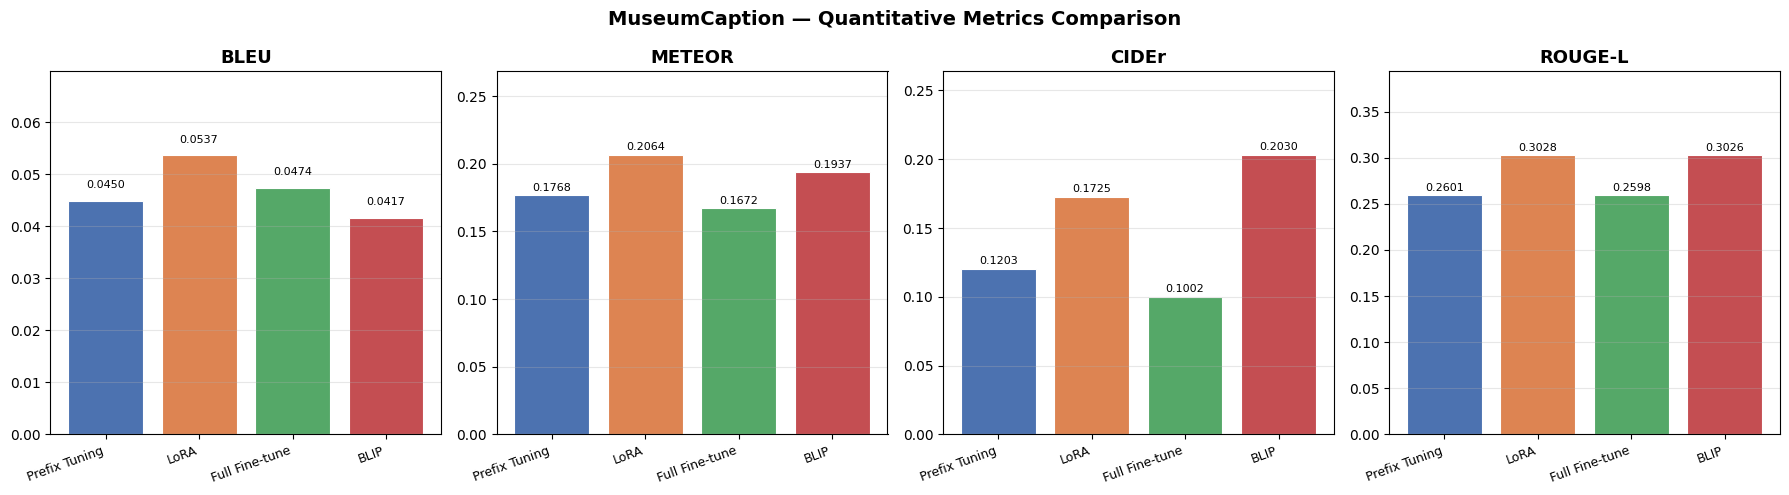

Metrics chart saved.


In [ ]:
# Cell 20 — Metrics Bar Chart
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metric_names = ["BLEU", "METEOR", "CIDEr", "ROUGE-L"]
colors       = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
model_names  = list(metrics_results.keys())

for ax, metric in zip(axes, metric_names):
    vals = [metrics_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("MuseumCaption — Quantitative Metrics Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{M3_DIR}/metrics_bar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Metrics chart saved.")

In [ ]:
# Cell 21 — Parameter Sensitivity: Beam Width
img  = eval_data[0]["image"]
ref  = eval_results["refs"][0]
print(f"Reference: {ref}\n")
print("Beam Width Sensitivity (Prefix Model)")
print("=" * 55)

beam_results = {}
for bw in [1, 3, 5, 7, 10]:
    cap = generate_caption_gpt2(img, gpt2_prefix, prefix_proj, beam_width=bw)
    beam_results[bw] = cap
    print(f"  beam_width={bw:2d}: {cap}")

Reference: The man with pierced ears is wearing glasses and an orange hat.

Beam Width Sensitivity (Prefix Model)
  beam_width= 1: a man with a beard and a beard
  beam_width= 3: a man with a beard and a mustache
  beam_width= 5: a man wearing a shirt with the words "I'm a man" on it
  beam_width= 7: a man wearing a baseball cap with a baseball bat on his head.
  beam_width=10: a man wearing a baseball cap with a baseball bat on his head and a baseball glove on his arm.


In [ ]:
# Cell 22 — Parameter Sensitivity: Temperature (Nucleus Sampling)
print(f"\nReference: {ref}\n")
print("Temperature Sensitivity (Nucleus Sampling, Prefix Model)")
print("=" * 55)

temp_results = {}
for temp in [0.5, 0.7, 0.85, 1.0, 1.2]:
    prompt        = "a photo of"
    img_emb       = get_image_embedding(img)
    prefix        = prefix_proj(img_emb)
    text_ids      = gpt2_tokenizer(prompt, return_tensors="pt").to(device)["input_ids"]
    text_emb      = gpt2_prefix.transformer.wte(text_ids)
    inputs_embeds = torch.cat([prefix, text_emb], dim=1)
    attn_mask     = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)
    with torch.no_grad():
        out = gpt2_prefix.generate(
            inputs_embeds=inputs_embeds, attention_mask=attn_mask,
            max_new_tokens=50, do_sample=True,
            top_p=0.9, temperature=temp,
            no_repeat_ngram_size=3,
            pad_token_id=gpt2_tokenizer.eos_token_id
        )
    cap = clean_caption(gpt2_tokenizer.decode(out[0], skip_special_tokens=True))
    temp_results[temp] = cap
    print(f"  temp={temp}: {cap}")


Reference: The man with pierced ears is wearing glasses and an orange hat.

Temperature Sensitivity (Nucleus Sampling, Prefix Model)
  temp=0.5: a man with a beard
  temp=0.7: a man with a mane of white hair and a man's head.
  temp=0.85: a man wearing a baseball cap, a baseball bat and a baseball glove
  temp=1.0: a man with his hands over his head, holding a bottle
  temp=1.2: a man leaning on the back of a dog


In [ ]:
#  Cell 23 — Decoding Strategy Comparison (all 3 models)
print(f"\nReference: {ref}\n")
print("Decoding Strategy Comparison")
print("=" * 65)

def get_wte(gpt2_mdl):
    """Get word token embedding regardless of model type (PEFT or base)."""
    try:
        return gpt2_mdl.transformer.wte
    except AttributeError:
        try:
            return gpt2_mdl.base_model.transformer.wte
        except AttributeError:
            return gpt2_mdl.base_model.model.model.transformer.wte

strategies = {
    "Greedy":            {"do_sample": False, "num_beams": 1},
    "Beam Search (w=5)": {"do_sample": False, "num_beams": 5},
    "Nucleus (p=0.9)":   {"do_sample": True,  "top_p": 0.9, "temperature": 0.85}
}

decoding_results = {}
for strat_name, gen_kw in strategies.items():
    row = {}
    for model_name, (gpt2_mdl, pfx) in [
        ("Prefix", (gpt2_prefix, prefix_proj)),
        ("LoRA",   (gpt2_lora,   prefix_lora)),
        ("Full FT",(gpt2_full,   prefix_full))
    ]:
        prompt        = "a photo of"
        img_emb       = get_image_embedding(img)
        prefix        = pfx(img_emb)
        text_ids      = gpt2_tokenizer(prompt, return_tensors="pt").to(device)["input_ids"]
        text_emb      = get_wte(gpt2_mdl)(text_ids)
        inputs_embeds = torch.cat([prefix, text_emb], dim=1)
        attn_mask     = torch.ones(inputs_embeds.shape[:2], dtype=torch.long, device=device)
        with torch.no_grad():
            out = gpt2_mdl.generate(
                inputs_embeds=inputs_embeds, attention_mask=attn_mask,
                max_new_tokens=50, no_repeat_ngram_size=3,
                pad_token_id=gpt2_tokenizer.eos_token_id, **gen_kw
            )
        cap = clean_caption(gpt2_tokenizer.decode(out[0], skip_special_tokens=True))
        row[model_name] = cap
        print(f"  [{strat_name:20s}] {model_name:8s}: {cap}")
    decoding_results[strat_name] = row
print()


Reference: The man with pierced ears is wearing glasses and an orange hat.

Decoding Strategy Comparison
  [Greedy              ] Prefix  : a man with a beard
  [Greedy              ] LoRA    : a man in a hat and sunglasses with a red hat and glasses.
  [Greedy              ] Full FT : a man in a red shirt and jeans sitting on a bench with a guitar and a microphone.
  [Beam Search (w=5)   ] Prefix  : a man with a beard
  [Beam Search (w=5)   ] LoRA    : a man wearing a hat and sunglasses with a smile on his face.
  [Beam Search (w=5)   ] Full FT : a man in a blue shirt and a woman in a red shirt standing in front of a building.
  [Nucleus (p=0.9)     ] Prefix  : a man wearing a shirt with a cap on his head
  [Nucleus (p=0.9)     ] LoRA    : a man in a hat, wearing a gray shirt and dark sunglasses, holding a computer.
  [Nucleus (p=0.9)     ] Full FT : a man in a black jacket sitting and smoking a cigarette.



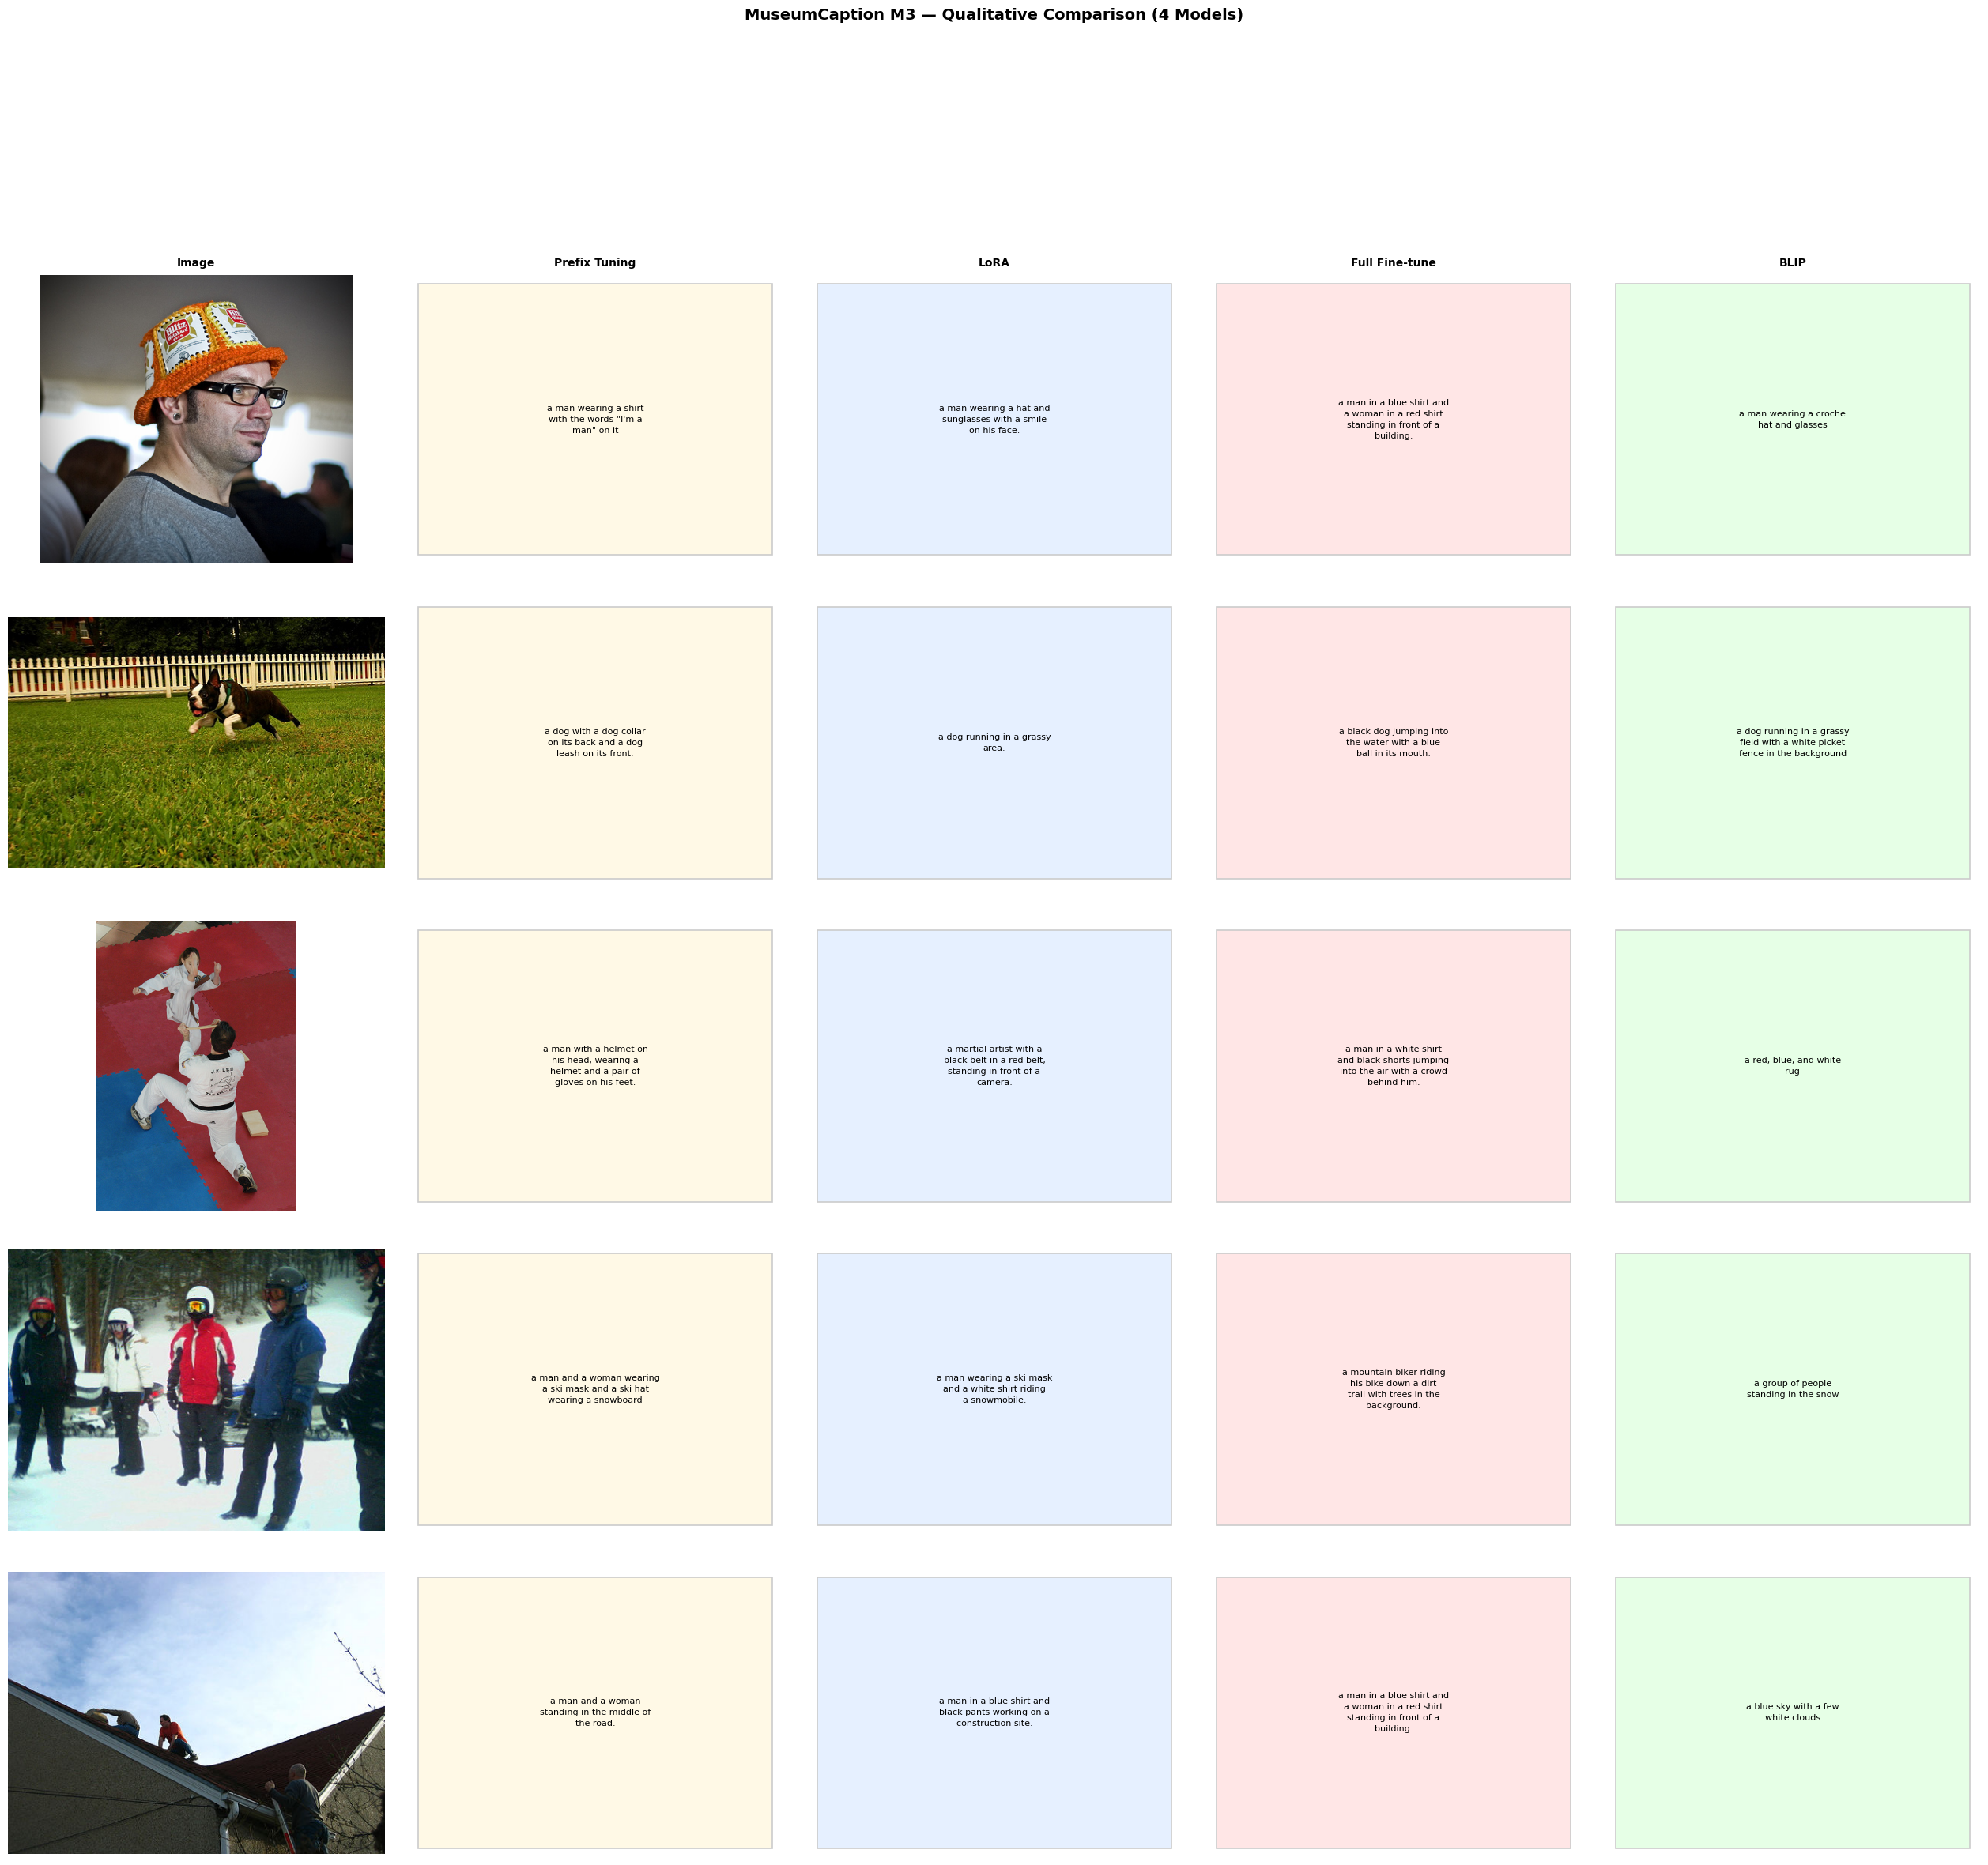

Qualitative gallery saved.


In [ ]:
# Cell 24 — Qualitative Gallery (5 images × 4 models)
fig = plt.figure(figsize=(26, 26))
model_keys   = ["prefix", "lora", "full", "blip"]
model_labels = ["Prefix Tuning", "LoRA", "Full Fine-tune", "BLIP"]
colors       = ["#fff9e6", "#e6f0ff", "#ffe6e6", "#e6ffe6"]

for i in range(5):
    img = eval_data[i]["image"]
    ref = eval_results["refs"][i]

    ax_img = fig.add_subplot(5, 5, i * 5 + 1)
    ax_img.imshow(img)
    ax_img.axis("off")
    if i == 0:
        ax_img.set_title("Image", fontsize=10, fontweight="bold", pad=8)

    for j, (key, label, color) in enumerate(zip(model_keys, model_labels, colors)):
        ax = fig.add_subplot(5, 5, i * 5 + j + 2)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")
        cap     = eval_results[key][i]
        wrapped = "\n".join(textwrap.wrap(cap, width=25))
        ax.add_patch(plt.Rectangle((0.03, 0.03), 0.94, 0.94,
                                    facecolor=color, edgecolor="#ccc", linewidth=1.2))
        ax.text(0.5, 0.5, wrapped, ha="center", va="center",
                fontsize=8, linespacing=1.5, zorder=5)
        if i == 0:
            ax.set_title(label, fontsize=10, fontweight="bold", pad=8)

plt.suptitle("MuseumCaption M3 — Qualitative Comparison (4 Models)",
             fontsize=14, fontweight="bold", y=1.01)
plt.subplots_adjust(left=0.02, right=0.98, wspace=0.06, hspace=0.12)
plt.savefig(f"{M3_DIR}/qualitative_gallery.png", dpi=150, bbox_inches="tight")
plt.show()
print("Qualitative gallery saved.")

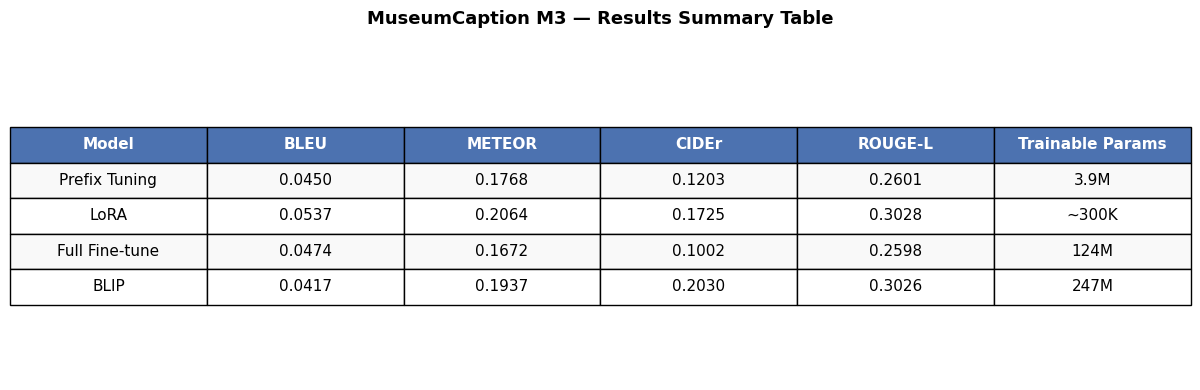

Summary table saved.


In [ ]:
# Cell 25 — Summary Table Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

cols     = ["Model", "BLEU", "METEOR", "CIDEr", "ROUGE-L", "Trainable Params"]
params   = {"Prefix Tuning": "3.9M", "LoRA": "~300K", "Full Fine-tune": "124M", "BLIP": "247M"}
rows     = []
for name in model_names:
    m = metrics_results[name]
    rows.append([name,
                 f"{m['BLEU']:.4f}",
                 f"{m['METEOR']:.4f}",
                 f"{m['CIDEr']:.4f}",
                 f"{m['ROUGE-L']:.4f}",
                 params[name]])

table = ax.table(cellText=rows, colLabels=cols, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# Header styling
for j in range(len(cols)):
    table[0, j].set_facecolor("#4C72B0")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Row alternating colors
for i, row in enumerate(rows):
    bg = "#f9f9f9" if i % 2 == 0 else "#ffffff"
    for j in range(len(cols)):
        table[i+1, j].set_facecolor(bg)

plt.title("MuseumCaption M3 — Results Summary Table",
          fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(f"{M3_DIR}/results_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Summary table saved.")

📁 Upload any image (jpg/png):


Saving Test 3.jpg to Test 3.jpg

📷 Test 3.jpg
  Prefix   : a man in a wheelchair sitting on a bench in the middle of the street. The man is wearing a T-shirt with a picture of himself on the front and a photo of a woman on the back.
  LoRA     : a young woman sitting on a rock in the middle of the woods.
  Full FT  : a man in a blue shirt and a woman in a red shirt standing in front of a building.
  BLIP     : a man and a woman sitting on a bench in the woods


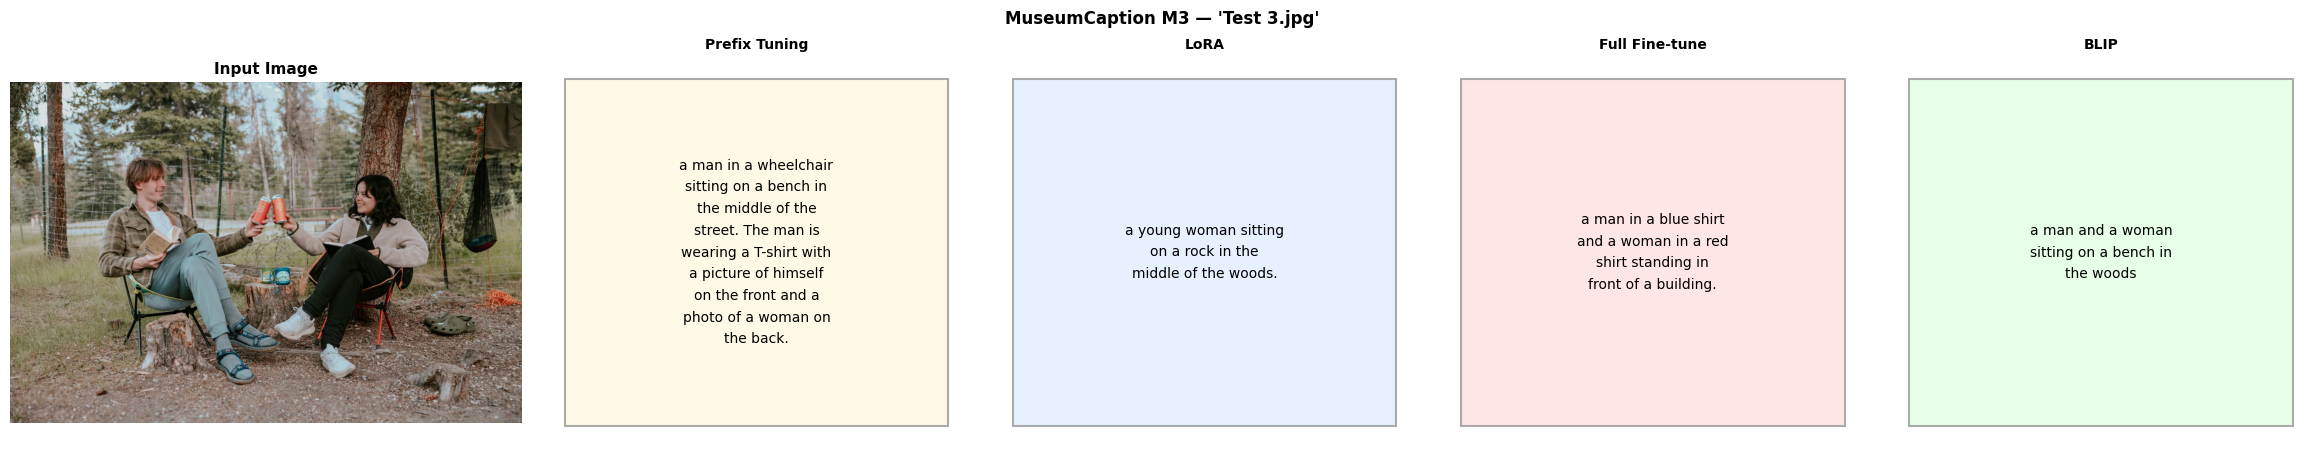

✓ Saved to Drive.


In [ ]:
# Cell 26 — Upload any image and caption with all 4 models
from google.colab import files
import textwrap

print("📁 Upload any image (jpg/png):")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
img      = Image.open(img_name).convert("RGB")

# Generate captions
cap_prefix = generate_caption_gpt2(img, gpt2_prefix, prefix_proj)
cap_lora   = generate_caption_gpt2(img, gpt2_lora,   prefix_lora)
cap_full   = generate_caption_gpt2(img, gpt2_full,   prefix_full)
cap_blip   = generate_caption_blip(img)

print(f"\n📷 {img_name}")
print(f"  Prefix   : {cap_prefix}")
print(f"  LoRA     : {cap_lora}")
print(f"  Full FT  : {cap_full}")
print(f"  BLIP     : {cap_blip}")

# Display
fig, axes = plt.subplots(1, 5, figsize=(24, 5),
                          gridspec_kw={"width_ratios": [1.2,1,1,1,1]})
axes[0].imshow(img)
axes[0].set_title("Input Image", fontsize=11, fontweight="bold")
axes[0].axis("off")

for ax, cap, title, color in [
    (axes[1], cap_prefix, "Prefix Tuning", "#fff9e6"),
    (axes[2], cap_lora,   "LoRA",          "#e6f0ff"),
    (axes[3], cap_full,   "Full Fine-tune","#ffe6e6"),
    (axes[4], cap_blip,   "BLIP",          "#e6ffe6"),
]:
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9,
                                facecolor=color, edgecolor="#aaa", linewidth=1.5))
    ax.text(0.5, 0.5, "\n".join(textwrap.wrap(cap, width=22)),
            ha="center", va="center", fontsize=10,
            linespacing=1.7, zorder=5)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

plt.suptitle(f"MuseumCaption M3 — '{img_name}'", fontsize=12, fontweight="bold")
plt.subplots_adjust(left=0.02, right=0.98, wspace=0.05)
plt.savefig(f"{M3_DIR}/custom_{img_name.split('.')[0]}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved to Drive.")

Results folder: /content/drive/MyDrive/MuseumCaption/milestone3/Results

📁 Upload any image (jpg/png):


Saving Test 3.jpg to Test 3 (1).jpg

📷 Test 3 (1).jpg
  Prefix   : a man in a wheelchair sitting on a bench in the middle of the street. The man is wearing a T-shirt with a picture of himself on the front and a photo of a woman on the back.
  LoRA     : a young woman sitting on a rock in the middle of the woods.
  Full FT  : a man in a blue shirt and a woman in a red shirt standing in front of a building.
  BLIP     : a man and a woman sitting on a bench in the woods


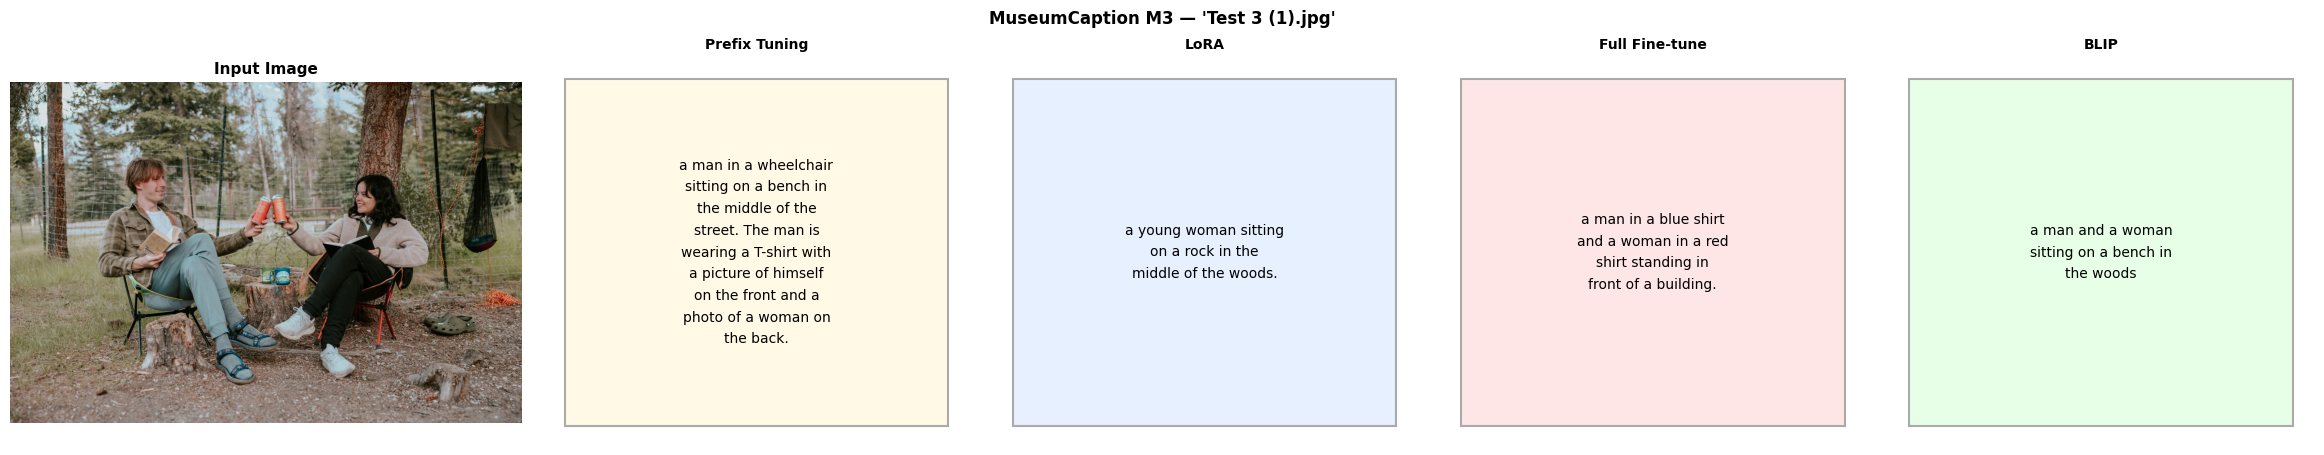

✓ Saved to: /content/drive/MyDrive/MuseumCaption/milestone3/Results/Test_3_(1)_comparison.png
✓ Captions JSON saved to: /content/drive/MyDrive/MuseumCaption/milestone3/Results/Test_3_(1)_captions.json


In [ ]:
# Cell 26 — Upload any image, caption with all 4 models, save to Results folder
from google.colab import files
import textwrap

RESULTS_DIR = f"{M3_DIR}/Results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results folder: {RESULTS_DIR}")

print("\n📁 Upload any image (jpg/png):")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
img      = Image.open(img_name).convert("RGB")

# Generate captions
cap_prefix = generate_caption_gpt2(img, gpt2_prefix, prefix_proj)
cap_lora   = generate_caption_gpt2(img, gpt2_lora,   prefix_lora)
cap_full   = generate_caption_gpt2(img, gpt2_full,   prefix_full)
cap_blip   = generate_caption_blip(img)

print(f"\n📷 {img_name}")
print(f"  Prefix   : {cap_prefix}")
print(f"  LoRA     : {cap_lora}")
print(f"  Full FT  : {cap_full}")
print(f"  BLIP     : {cap_blip}")

# Display + save
fig, axes = plt.subplots(1, 5, figsize=(24, 5),
                          gridspec_kw={"width_ratios": [1.2,1,1,1,1]})
axes[0].imshow(img)
axes[0].set_title("Input Image", fontsize=11, fontweight="bold")
axes[0].axis("off")

for ax, cap, title, color in [
    (axes[1], cap_prefix, "Prefix Tuning", "#fff9e6"),
    (axes[2], cap_lora,   "LoRA",          "#e6f0ff"),
    (axes[3], cap_full,   "Full Fine-tune","#ffe6e6"),
    (axes[4], cap_blip,   "BLIP",          "#e6ffe6"),
]:
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9,
                                facecolor=color, edgecolor="#aaa", linewidth=1.5))
    ax.text(0.5, 0.5, "\n".join(textwrap.wrap(cap, width=22)),
            ha="center", va="center", fontsize=10,
            linespacing=1.7, zorder=5)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

plt.suptitle(f"MuseumCaption M3 — '{img_name}'",
             fontsize=12, fontweight="bold")
plt.subplots_adjust(left=0.02, right=0.98, wspace=0.05)

save_name = img_name.replace(" ", "_").split(".")[0]
save_path = f"{RESULTS_DIR}/{save_name}_comparison.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved to: {save_path}")

# Save captions as JSON too
import json
caption_log = {
    "image":   img_name,
    "prefix":  cap_prefix,
    "lora":    cap_lora,
    "full_ft": cap_full,
    "blip":    cap_blip
}
json_path = f"{RESULTS_DIR}/{save_name}_captions.json"
with open(json_path, "w") as f:
    json.dump(caption_log, f, indent=2)
print(f"✓ Captions JSON saved to: {json_path}")